# Experiments

in this notebook we run all 3 models 

In [1]:
# add the directory to the path so we can import modules
import sys
import os
sys.path.append(os.path.abspath('..'))


In [ ]:
import torch
import random
import numpy as np
import pandas as pd

from src.dataset import get_dataloaders, create_binary_dataset
from src.utils import train_model, logs_to_df, print_train_times, plot_curves, compare_models_latency, get_detailed_spike_metrics
from src.models.lstm import BaselineLSTM
from src.models.reservoirs import RandomLSM, StructuredLSNN

In [3]:
# Setup device and seed for reproducibility

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Running on {DEVICE}")

SEED = 0

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED) 

Running on mps


In [4]:
create_binary_dataset('../data/raw', '../data/processed')

Processing ECG5000_TRAIN.txt...
  Saved to ../data/processed/BINARY_ECG5000_TRAIN.txt
  Stats: Healthy=292, Unhealthy=208, Total=500
Processing ECG5000_TEST.txt...
  Saved to ../data/processed/BINARY_ECG5000_TEST.txt
  Stats: Healthy=2627, Unhealthy=1873, Total=4500


In [5]:
# load the dataset
train_loader, test_loader = get_dataloaders('../data/processed', batch_size=64, processed=True)

# define the models using the best parameters from the grid search
model_a = BaselineLSTM()
model_b = RandomLSM(input_scale=10, beta=0.9)
model_c = StructuredLSNN()

# train the models
print("Training LSTM Baseline")
model_a, hist_a = train_model(model_a, train_loader, test_loader, device=DEVICE, epochs=30, lr=0.001)
print("Training Random LSM")
model_b, hist_b = train_model(model_b, train_loader, test_loader, device=DEVICE, epochs=30, lr=0.005)
print("Training Structured LSNN")
model_c, hist_c = train_model(model_c, train_loader, test_loader, device=DEVICE, epochs=30, lr=0.005)




Training LSTM Baseline


Training:   0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

...

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

In [6]:
MODEL_LOGS = [
    {"name": "BaselineLSTM", "history": hist_a},
    {"name": "RandomLSM", "history": hist_b},
    {"name": "StructuredLSNN", "history": hist_c},
]

In [7]:
# convert the model logs to a dataframe
logs_to_df(MODEL_LOGS)

,model,epoch,train_loss,test_acc
0,BaselineLSTM,1,0.673052,85.822222
1,BaselineLSTM,2,0.547858,92.622222
2,BaselineLSTM,3,0.325447,90.800000
3,BaselineLSTM,4,0.238225,91.955556
4,BaselineLSTM,5,0.191123,93.133333
...,...,...,...,...
85,StructuredLSNN,26,0.097997,96.555556
86,StructuredLSNN,27,0.092356,96.622222
87,StructuredLSNN,28,0.087893,96.822222
88,StructuredLSNN,29,0.084638,97.000000


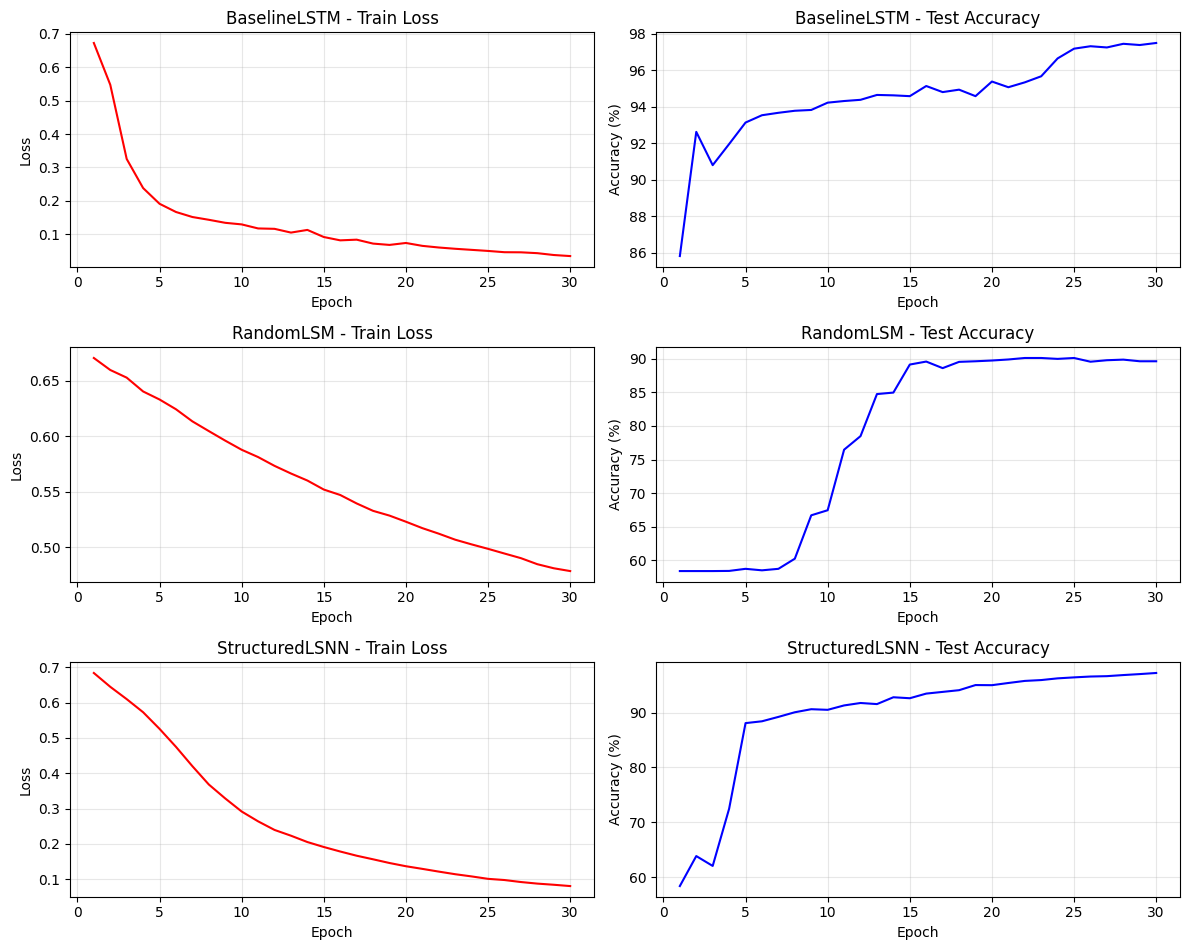

In [8]:
# plot the traing loss and accuracy curves for all models
plot_curves(MODEL_LOGS)

In [9]:
# print the training times for all models
print_train_times(MODEL_LOGS)

BaselineLSTM: 18.737375020980835 s
RandomLSM: 78.81569218635559 s
StructuredLSNN: 100.54237914085388 s


In [10]:
# compare the latency of all models
one_sample, _ = next(iter(test_loader))
one_sample = one_sample[0]  # [T, F] single entry

models = {
    "BaselineLSTM": model_a,
    "RandomLSM": model_b,
    "StructuredLSNN": model_c,
}
compare_models_latency(models, one_sample, device=DEVICE)

BaselineLSTM: 6.199 ms / sample
RandomLSM: 30.641 ms / sample
StructuredLSNN: 40.014 ms / sample
Fastest: BaselineLSTM


[('BaselineLSTM', 6.198614994063973),
 ('RandomLSM', 30.640798290260136),
 ('StructuredLSNN', 40.01411730889231)]

In [13]:
detailed_spike_metrics = get_detailed_spike_metrics(model_b, test_loader, DEVICE)
detailed_spike_metrics_lsnn = get_detailed_spike_metrics(model_c, test_loader, DEVICE)

print(f"Detailed Spike Metrics (LSM): {detailed_spike_metrics}")
print(f"Detailed Spike Metrics (LSNN): {detailed_spike_metrics_lsnn}")

Detailed Spike Metrics (LSM): {'spikes_per_sample': 962.9868888888889, 'sparsity_percent': 89.25237847222223, 'spike_density': 0.10747621527777777}
Detailed Spike Metrics (LSNN): {'spikes_per_sample': 2897.024, 'sparsity_percent': 71.25968253968253, 'spike_density': 0.2874031746031746}
